# Model Usage Example

This notebook demonstates the use of a model defined outside of the main Hyrax package.

In [1]:
from hyrax import Hyrax

h = Hyrax()

We'll update the configuration to use the VGG11 model defined in this package.
After specifying the model, we'll update one of the model parameters, enabling batch normalization.

In [2]:
h.set_config("model.name", "external_hyrax_example.models.vgg11.VGG11")
h.set_config("external_hyrax_example.VGG11.batch_norm", True)

[2026-03-17 12:48:47,602 hyrax.config_utils:INFO] Merging external default config from /home/drew/code/external_hyrax_example/src/external_hyrax_example/default_config.toml
[2026-03-17 12:48:47,612 hyrax.config_utils:INFO] Merging external default config from /home/drew/code/external_hyrax_example/src/external_hyrax_example/default_config.toml


We need to specify the data we're using too, we'll use the Hyrax Cifar dataset here.

In [3]:
data_request = {
    "train": {
        "data": {
            "dataset_class": "HyraxCifarDataset",
            "data_location": "./data",
            "fields": ["image", "label"],
            "primary_id_field": "object_id",
            "split_fraction": 1.0,
        },
    },
}
h.set_config("data_request", data_request)

[2026-03-17 12:48:47,639 hyrax.config_utils:INFO] Merging external default config from /home/drew/code/external_hyrax_example/src/external_hyrax_example/default_config.toml
[2026-03-17 12:48:47,646 hyrax.config_utils:WARNING] Runtime config contains key or section 'data_request' which has no default defined. All configuration keys and sections must be defined in /home/drew/code/hyrax/src/hyrax/hyrax_default_config.toml


In [ ]:
model = h.train()

In [5]:
data_request = {
    "infer": {
        "data": {
            "dataset_class": "HyraxCifarDataset",
            "data_location": "./data",
            "fields": ["image"],
            "primary_id_field": "object_id",
            "dataset_config": {
                "use_training_data": False,
            }
        },
    },
}
h.set_config("data_request", data_request)

[2026-03-17 12:52:14,974 hyrax.config_utils:INFO] Merging external default config from /home/drew/code/external_hyrax_example/src/external_hyrax_example/default_config.toml
[2026-03-17 12:52:14,981 hyrax.config_utils:WARNING] Runtime config contains key or section 'infer' which has no default defined. All configuration keys and sections must be defined in /home/drew/code/hyrax/src/hyrax/hyrax_default_config.toml


In [ ]:
results = h.infer()

## Evaluating the performance

Let's compare the models predictions to the actual labels from the test dataset.
The model's prediction is a 10 element vector where the largest value represents the highest confidence class.
So we'll extract the index of the max value for each prediction and save that as `predicted_classes`.

In [ ]:
# get the index of the maximum predicted class for all test samples
import numpy as np

predicted_classes = np.zeros(len(results)).astype(int)
for i in range(len(results)):
    predicted_classes[i] = results[i].argmax()


We'll also load the original test data to get access to the true labels.

In [ ]:
import pickle

with open("./data/cifar-10-batches-py/test_batch", "rb") as f_in:
    test_data = pickle.load(f_in, encoding="bytes")

/tmp/ipykernel_87340/3458004124.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  test_data = pickle.load(f_in, encoding="bytes")


Finally we'll print the overall accuracy and use scikit-learn's ``confusion_matrix`` to display a nice confusion matrix.


Accuracy for test dataset: 0.7013


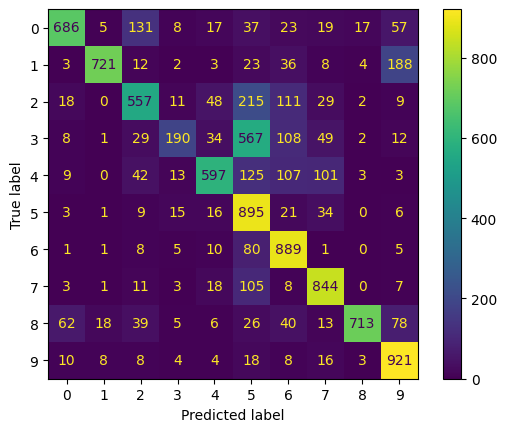

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_true = test_data[b"labels"]
y_pred = predicted_classes.tolist()

correct = 0
for t, p in zip(y_true, y_pred):
    correct += t == p

print("\nAccuracy for test dataset:", correct / len(y_true))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()